# Кластерный анализ

* [1. Иерархический кластерный анализ](#chapter1)
    * [Пример 1.1. Производство пива](#section_1_1)
    * [Пример 1.2. Оценка кандидатов](#section_1_2)
* [2. Кластерный анализ методом k-means](#chapter2)
    * [Example 2.1. Синтетические данные](#section_2_1)
    * [Example 2.2. Текучесть кадров и производительность труда](#section_2_2)
* [3. DBSCAN](#chapter3)
    * [Example 3.1. Синтетические данные](#section_3_1)
    * [Example 3.2. Сегментация клиентов торгового центра](#section_3_2)

In [1]:
#pip install yellowbrick
#pip install factor_analyzer

import pandas as pd
import numpy as np
import seaborn as sns
from itertools import product
from scipy.stats.mstats import zscore
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.cluster import KMeans, DBSCAN
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.metrics import calinski_harabasz_score, silhouette_score
from yellowbrick.cluster import KElbowVisualizer
from factor_analyzer import FactorAnalyzer, Rotator, calculate_bartlett_sphericity, calculate_kmo
import warnings
warnings.filterwarnings("ignore")

## 1. Иерархический кластерный анализ <a class="anchor" id="chapter1"></a>

### Пример 1.1. Производство пива (файл beer.xlsx) <a id="section_1_1"></a>

Описание переменных:
- bier - название бренда
- producer - название производителя
- costs - расходы в долларах на производство объёма, равного 12 унциям
- calories - количество калорий на 12 унций
- alcohol - содержание алкоголя в процентах

In [2]:
df1 = pd.read_excel('beer.xlsx')
df1

,bier,producer,costs,calories,alcohol
0,Budweiser,USA,0.43,144,4.7
1,Lowenbrau,USA,0.48,157,4.9
2,Michelob,USA,0.50,162,5.0
3,Kronenbourg,France,0.73,170,5.2
4,Heineken,Holland,0.77,152,5.0
5,Schmidts,USA,0.30,147,4.7
6,Pabst Blue Ribbon,USA,0.38,152,4.9
7,Miller Light,USA,0.43,99,4.3
8,Budweiser Light,USA,0.44,113,3.7
9,Coors Light,USA,0.46,102,4.1


Проверим корреляцию признаков. Не стоит проводить кластеризацию с признаками, имеющими сильнейшую корреляцию между собой. Новое знание о данных вы не получите, а структура кластеров будет искусственно усилена и искажена. Либо можно исключить одну из сильно коррелирующих переменны, либо провести PCA.

In [3]:
df1.corr()

,costs,calories,alcohol
costs,1.000000,0.359428,0.318681
calories,0.359428,1.000000,0.919873
alcohol,0.318681,0.919873,1.000000


### Предварительный графический анализ данных

Начнем с очень простого примера. Кластеризуем бренды пива на основе двух признаков: калорийность и расходы на производство. Между ними наблюдается слабая корреляция.

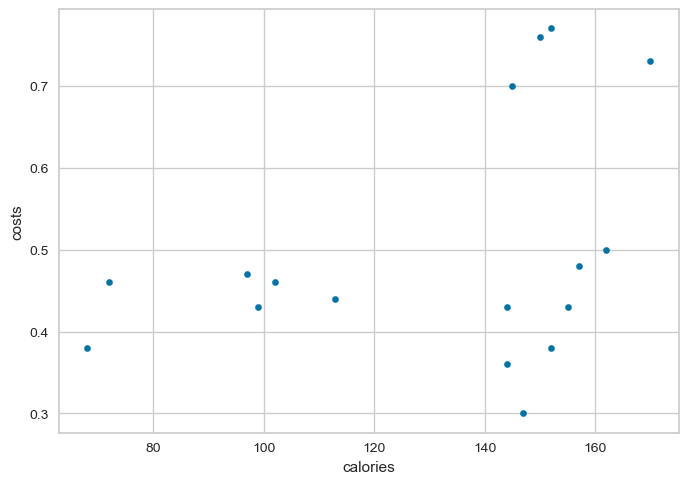

In [4]:
df1.plot('calories', 'costs', kind='scatter'); 

Признаки измерены в разных шкалах, поэтому стандартизируем их значения с помощью z-стандартизации.

<Axes: xlabel='z_calories', ylabel='z_costs'>

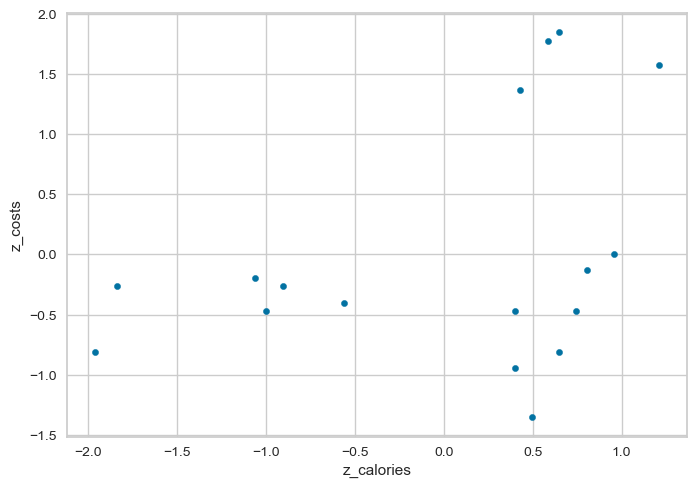

In [5]:
df1['z_calories'] = (df1['calories'] - df1['calories'].mean())/df1['calories'].std()
df1['z_costs'] = (df1['costs'] - df1['costs'].mean())/df1['costs'].std()
df1.plot('z_calories', 'z_costs', kind='scatter')

Изменились шакалы, но соотношения точек на графике не поменялись. Итак, сколько кластеров вы видите на графике?

Применим иерархическую кластеризацию, визуализировав ее на дендрограмме.

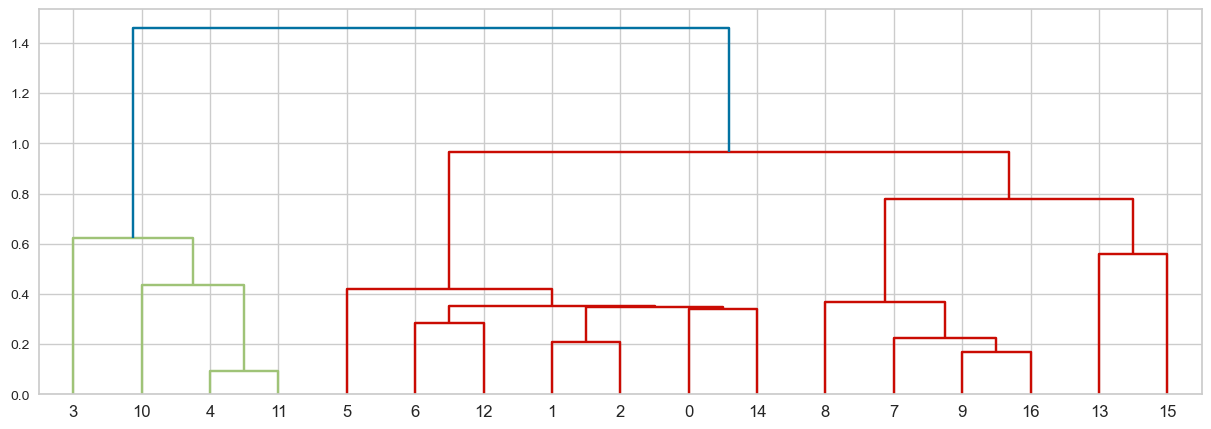

In [6]:
plt.figure(figsize=(15, 5))
dn = dendrogram(linkage(df1[['z_calories', 'z_costs']], 'single'))
# Близлежащий сосед / Nearest neighbor / Single-linkage

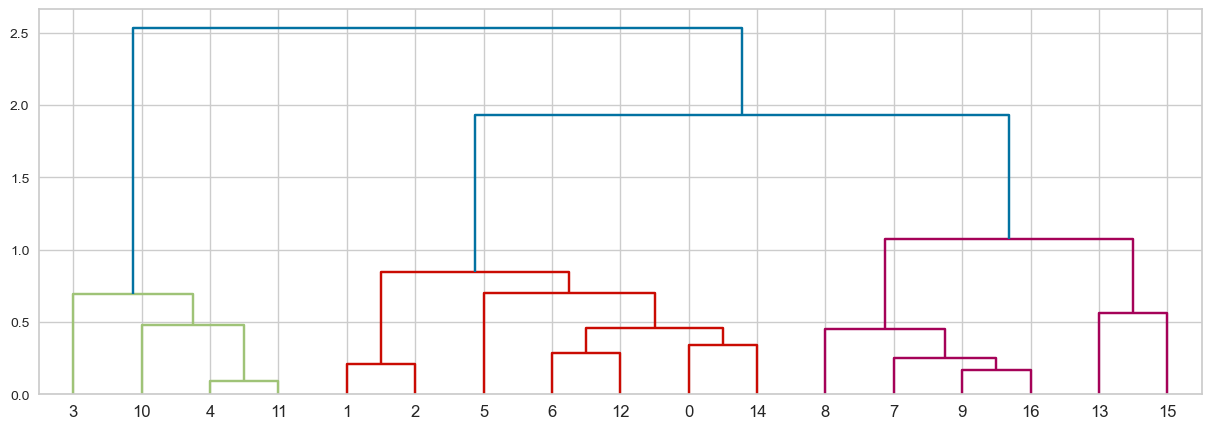

In [7]:
plt.figure(figsize=(15, 5))
dn = dendrogram(linkage(df1[['z_calories', 'z_costs']], 'average'))
# Межгрупповые связи / Average Linkage / Between Groups Linkage

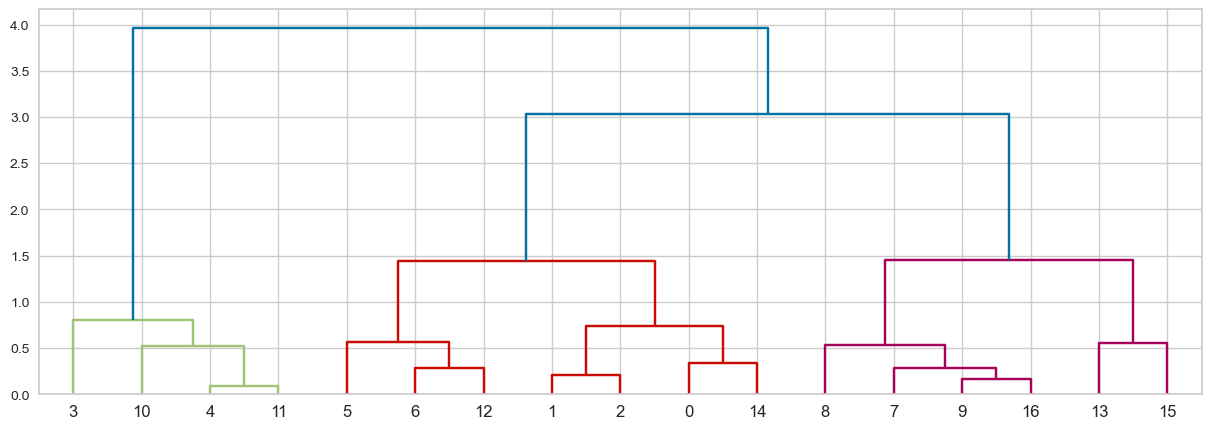

In [8]:
plt.figure(figsize=(15, 5))
dn = dendrogram(linkage(df1[['z_calories', 'z_costs']], 'complete'))
# Дальний сосед / Furthest neighbor / Complete-linkage

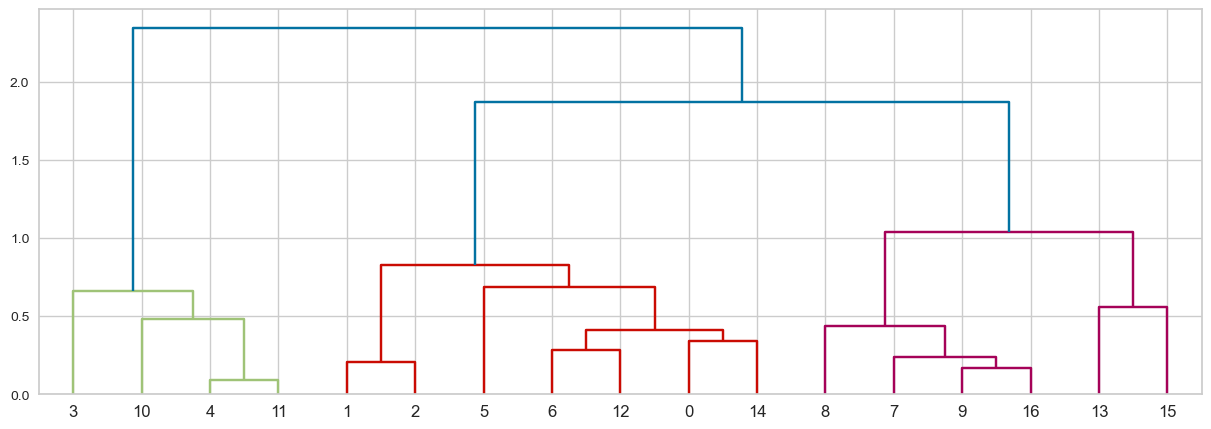

In [9]:
plt.figure(figsize=(15, 5))
dn = dendrogram(linkage(df1[['z_calories', 'z_costs']], 'centroid'))
# Центроидная кластеризация / Centroid Clustering

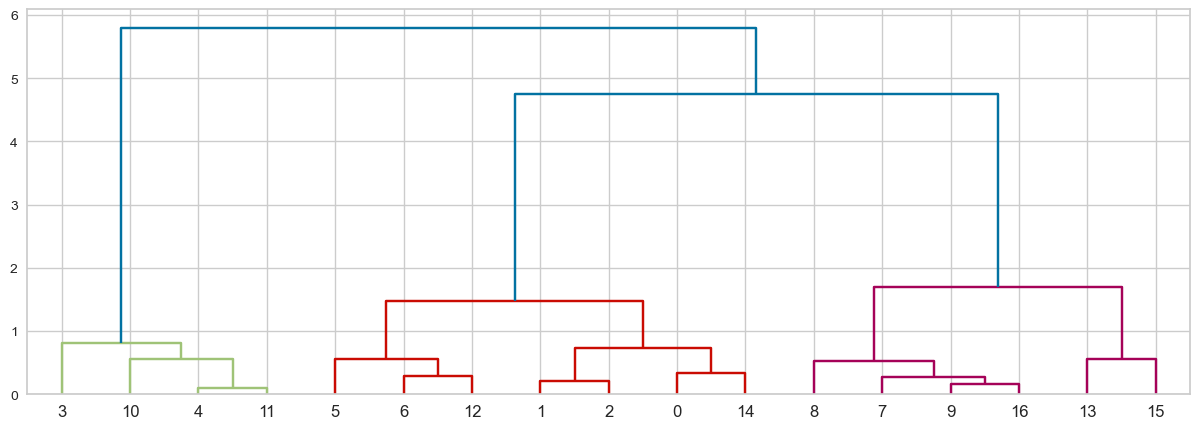

In [10]:
plt.figure(figsize=(15, 5))
dn = dendrogram(linkage(df1[['z_calories', 'z_costs']], 'ward'))
# Метод Варда

Посмотрим на денрограмму, построенную на основе метода Варда. Кажется, что тут может быть от 3 до 5 кластеров. Рассчитаем значения индекса Калински-Харабаша для диапазона кластеров от 2 до 9, чтобы была конкретная метрика, которая нам подскажет оптимальное число кластеров с точки зрения внутрикластерной и межкластерной дисперсии. 

### [Индекс Калински-Харабаша](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.calinski_harabasz_score.html)

In [11]:
X = df1[['z_calories', 'z_costs']]

Z = linkage(X, method='ward', metric='euclidean')

ks = range(2, 10)
scores = []

for k in ks:
    labels = fcluster(Z, t=k, criterion='maxclust')
    score = calinski_harabasz_score(X, labels)
    scores.append(score)
    print(f'Число кластеров: {k}, Индекс Калински-Харабаша: {score:.2f}')

Число кластеров: 2, Индекс Калински-Харабаша: 16.64
Число кластеров: 3, Индекс Калински-Харабаша: 50.33
Число кластеров: 4, Индекс Калински-Харабаша: 51.80
Число кластеров: 5, Индекс Калински-Харабаша: 67.05
Число кластеров: 6, Индекс Калински-Харабаша: 65.19
Число кластеров: 7, Индекс Калински-Харабаша: 66.63
Число кластеров: 8, Индекс Калински-Харабаша: 64.59
Число кластеров: 9, Индекс Калински-Харабаша: 67.00


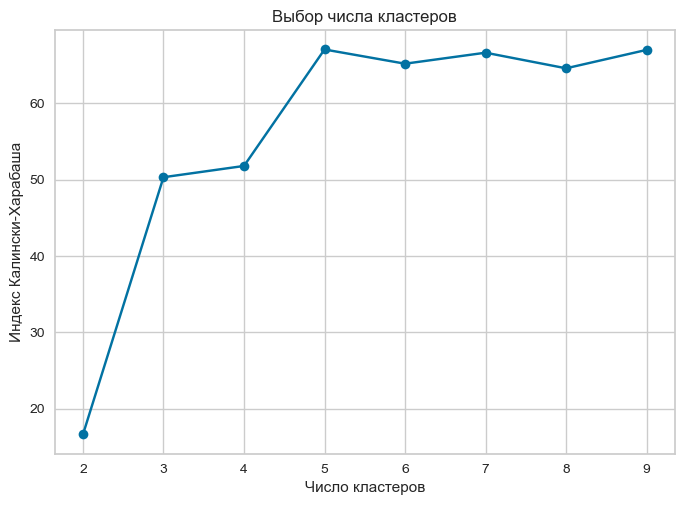

In [12]:
plt.plot(ks, scores, marker='o')
plt.xlabel('Число кластеров')
plt.ylabel('Индекс Калински-Харабаша')
plt.title('Выбор числа кластеров')
plt.show()

Индекс нам подсказывает, что лучше выбрать 5 кластеров. Мы не обязаны полагаться только на значение индекса. Может так получиться, что сравнив решение из 4 и 5 кластеров мы поймем, что 5-ый кластер не сильно отличатся по своим характеристикам, например, от 4-го. Поэтому не стоит его выделять в отдельную группу и лучше остановиться на 4 кластерах. Или, наоборот, один из кластеров получился слишком разнородным и лучше его разбить на 2, тогда в сумме получится 6 кластеров. 

Выведем метки, определяющие принадлежность каждого объекта к одному из 5-ти кластеров.

In [13]:
labels = fcluster(Z, t=5, criterion='maxclust')  # проводим рассчёты для 5-ти кластеров
labels

array([3, 3, 3, 1, 1, 2, 2, 4, 4, 4, 1, 1, 2, 5, 3, 5, 4], dtype=int32)

Дабавим в датасет новую переменную, отражающую принадлежность объекта к кластеру.

In [14]:
df1['culster_labels'] = labels
df1

,bier,producer,costs,calories,alcohol,z_calories,z_costs,culster_labels
0,Budweiser,USA,0.43,144,4.7,0.400407,-0.468980,3
1,Lowenbrau,USA,0.48,157,4.9,0.804471,-0.128268,3
2,Michelob,USA,0.50,162,5.0,0.959880,0.008017,3
3,Kronenbourg,France,0.73,170,5.2,1.208535,1.575291,1
4,Heineken,Holland,0.77,152,5.0,0.649062,1.847861,1
5,Schmidts,USA,0.30,147,4.7,0.493653,-1.354830,2
6,Pabst Blue Ribbon,USA,0.38,152,4.9,0.649062,-0.809692,2
7,Miller Light,USA,0.43,99,4.3,-0.998275,-0.468980,4
8,Budweiser Light,USA,0.44,113,3.7,-0.563130,-0.400837,4
9,Coors Light,USA,0.46,102,4.1,-0.905030,-0.264553,4


Рассчитаем средние значений признаков по кластерам. Берем исходные переменные до стандартизации, чтобы было понятней при интерпретации в каких шкалах измеряются признаки.

In [15]:
df1.groupby('culster_labels')[['costs', 'calories']].mean()

,costs,calories
culster_labels,,
1,0.740000,154.250000
2,0.346667,147.666667
3,0.460000,154.500000
4,0.450000,102.750000
5,0.420000,70.000000


Также для ориентира рассчитаем средние значения признаков по выборке в целом.

In [16]:
df1[['costs', 'calories']].mean()

costs         0.498824
calories    131.117647
dtype: float64

Выведем число наблюдений в каждом кластере.

In [17]:
df1['culster_labels'].value_counts()

3    4
1    4
4    4
2    3
5    2
Name: culster_labels, dtype: int64

Теперь вместе попробуем описать кластеры.

In [18]:
# Добавить сюда описание кластеров

### Пример 1.2. Оценка кандидатов (assess.xlsx) <a id="section_1_2"></a>

Описание переменных:

    nr  - Идентификатор кандидата 
    name - Имя кандидата
    t1 - Память на числа
    t2 - Математические навыки
    t3 - Готовность к прямому диалогу
    t4 - Умение разрабатывать алгоритмы
    t5 - Уверенность в речи
    t6 - Командный дух
    t7 - Находчивость
    t8 - Навыки сотрудничества
    t9 - Признание со стороны окружающих
    t10 - Умение убеждать

In [19]:
df2 = pd.read_excel('assess.xlsx', index_col=0)
df2

,name,t1,t2,t3,t4,t5,t6,t7,t8,t9,t10
nr,,,,,,,,,,,
1,Volker R,10,10,9,10,10,10,9,10,10,9
2,Sigrid K,10,10,4,10,5,5,4,5,4,3
3,Elmar M,5,4,10,5,10,4,10,5,3,10
4,Peter B,10,10,9,10,10,10,9,10,10,9
5,Otto R,4,3,5,4,3,10,4,10,10,5
6,Elke M,10,10,4,10,5,4,3,4,5,5
7,Sarah K,4,4,5,5,4,10,5,10,10,6
8,Peter T,4,5,3,4,5,10,4,10,10,4
9,Gudrun M,4,5,10,4,10,5,10,4,3,10


In [20]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 18 entries, 1 to 18
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   name    18 non-null     object
 1   t1      18 non-null     int64 
 2   t2      18 non-null     int64 
 3   t3      18 non-null     int64 
 4   t4      18 non-null     int64 
 5   t5      18 non-null     int64 
 6   t6      18 non-null     int64 
 7   t7      18 non-null     int64 
 8   t8      18 non-null     int64 
 9   t9      18 non-null     int64 
 10  t10     18 non-null     int64 
dtypes: int64(10), object(1)
memory usage: 1.7+ KB


In [21]:
df2.corr()

,t1,t2,t3,t4,t5,t6,t7,t8,t9,t10
t1,1.000000,9.677769e-01,-0.143309,0.951504,-0.005476,0.022828,-0.176399,0.067439,9.152717e-02,-0.171530
t2,0.967777,1.000000e+00,-0.043728,0.963437,0.108318,-0.075253,-0.079249,-0.048415,4.764132e-17,-0.084956
t3,-0.143309,-4.372811e-02,1.000000,-0.018181,0.942645,-0.262122,0.975636,-0.263429,-2.553715e-01,0.970465
t4,0.951504,9.634370e-01,-0.018181,1.000000,0.080316,-0.081352,-0.083874,-0.032352,0.000000e+00,-0.073055
t5,-0.005476,1.083184e-01,0.942645,0.080316,1.000000,-0.214410,0.965146,-0.187395,-1.881513e-01,0.934999
t6,0.022828,-7.525347e-02,-0.262122,-0.081352,-0.214410,1.000000,-0.165480,0.962489,9.668540e-01,-0.143647
t7,-0.176399,-7.924911e-02,0.975636,-0.083874,0.965146,-0.165480,1.000000,-0.160252,-1.618229e-01,0.972594
t8,0.067439,-4.841538e-02,-0.263429,-0.032352,-0.187395,0.962489,-0.160252,1.000000,9.631975e-01,-0.143159
t9,0.091527,4.764132e-17,-0.255371,0.000000,-0.188151,0.966854,-0.161823,0.963198,1.000000e+00,-0.117963
t10,-0.171530,-8.495567e-02,0.970465,-0.073055,0.934999,-0.143647,0.972594,-0.143159,-1.179633e-01,1.000000


Между некоторыми переменными наблюдается сильнейшая корреляция. Попробуем снизить размерность с помощью PCA.

In [22]:
df2 = df2.drop(columns=['name'])  # удалим столбец name

In [23]:
model1 = FactorAnalyzer(n_factors=10, rotation='varimax', method='principal') 
# строим модель для 10 компонент, что соответствует общему числу переменных
model1.fit(df2)

FactorAnalyzer(method='principal', n_factors=10, rotation='varimax',
               rotation_kwargs={})

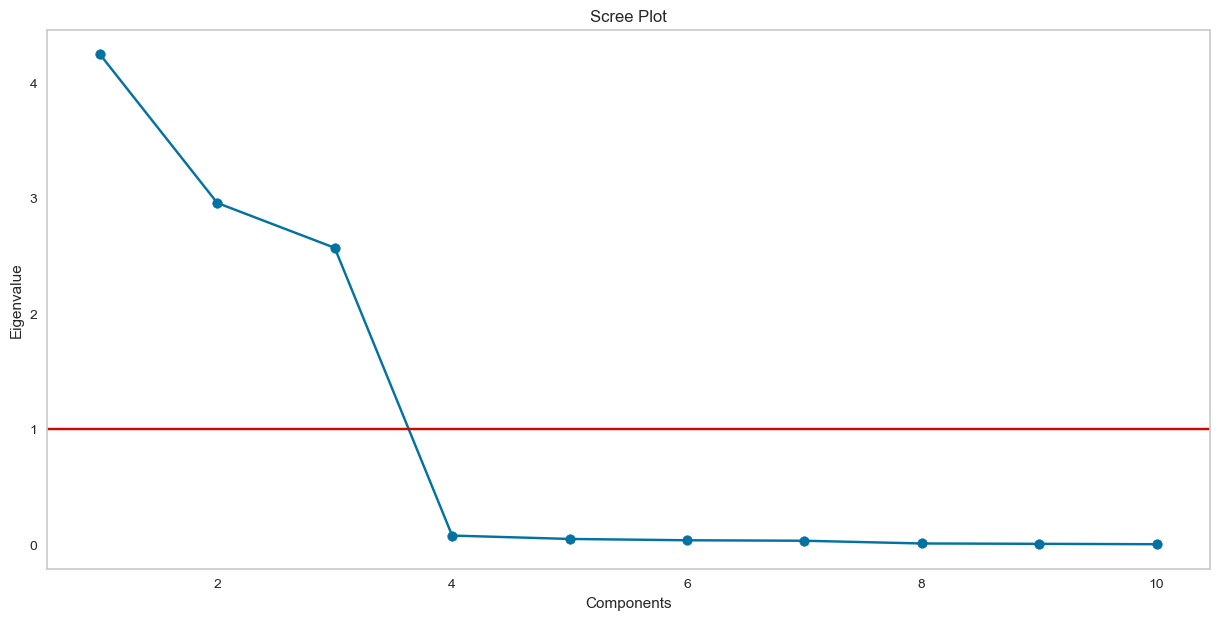

In [24]:
ev, v = model1.get_eigenvalues()

plt.figure(figsize=(15, 7))
plt.scatter(range(1, df2.shape[1]+1), ev)
plt.plot(range(1, df2.shape[1]+1), ev)
plt.axhline(y=1, color='r', linestyle='-')
plt.title('Scree Plot')
plt.xlabel('Components')
plt.ylabel('Eigenvalue')
plt.grid()
plt.show()

Оставляем три компоненты с собственными значениями больше 1 и перестраиваем модель.

In [25]:
model1 = FactorAnalyzer(n_factors=3, rotation='varimax', method='principal') 
# строим модель для 3 компонент
model1.fit(df2)

FactorAnalyzer(method='principal', rotation='varimax', rotation_kwargs={})

In [26]:
model_loadings = pd.DataFrame(data=model1.loadings_, 
                       index=df2.columns, 
                       columns=['Component_1', 'Component_2', 'Component_3'])

model_loadings.index = ['Память на числа', 'Математические навыки', 'Готовность к прямому диалогу',
                        'Умение разрабатывать алгоритмы', 'Уверенность в речи', 'Командный дух',
                        'Находчивость', 'Навыки сотрудничества', 'Признание со стороны окружающих',
                        'Умение убеждать']

model_loadings

,Component_1,Component_2,Component_3
Память на числа,-0.093040,0.983723,0.057788
Математические навыки,-0.000039,0.991036,-0.037143
Готовность к прямому диалогу,0.974758,-0.040956,-0.167518
Умение разрабатывать алгоритмы,0.001482,0.984280,-0.034353
Уверенность в речи,0.973198,0.093368,-0.101607
Командный дух,-0.108202,-0.044655,0.982014
Находчивость,0.989363,-0.084376,-0.066172
Навыки сотрудничества,-0.098968,-0.002521,0.982163
Признание со стороны окружающих,-0.089464,0.032870,0.984805
Умение убеждать,0.983172,-0.081991,-0.038302


In [27]:
model_loadings.sort_values('Component_1', ascending=False)  # отсортируем матрицу по первому столбцу

,Component_1,Component_2,Component_3
Находчивость,0.989363,-0.084376,-0.066172
Умение убеждать,0.983172,-0.081991,-0.038302
Готовность к прямому диалогу,0.974758,-0.040956,-0.167518
Уверенность в речи,0.973198,0.093368,-0.101607
Умение разрабатывать алгоритмы,0.001482,0.984280,-0.034353
Математические навыки,-0.000039,0.991036,-0.037143
Признание со стороны окружающих,-0.089464,0.032870,0.984805
Память на числа,-0.093040,0.983723,0.057788
Навыки сотрудничества,-0.098968,-0.002521,0.982163
Командный дух,-0.108202,-0.044655,0.982014


In [28]:
model_loadings.sort_values('Component_2', ascending=False)  # отсортируем матрицу по второму столбцу

,Component_1,Component_2,Component_3
Математические навыки,-0.000039,0.991036,-0.037143
Умение разрабатывать алгоритмы,0.001482,0.984280,-0.034353
Память на числа,-0.093040,0.983723,0.057788
Уверенность в речи,0.973198,0.093368,-0.101607
Признание со стороны окружающих,-0.089464,0.032870,0.984805
Навыки сотрудничества,-0.098968,-0.002521,0.982163
Готовность к прямому диалогу,0.974758,-0.040956,-0.167518
Командный дух,-0.108202,-0.044655,0.982014
Умение убеждать,0.983172,-0.081991,-0.038302
Находчивость,0.989363,-0.084376,-0.066172


In [29]:
model_loadings.sort_values('Component_3', ascending=False)  # отсортируем матрицу по третьему столбцу

,Component_1,Component_2,Component_3
Признание со стороны окружающих,-0.089464,0.032870,0.984805
Навыки сотрудничества,-0.098968,-0.002521,0.982163
Командный дух,-0.108202,-0.044655,0.982014
Память на числа,-0.093040,0.983723,0.057788
Умение разрабатывать алгоритмы,0.001482,0.984280,-0.034353
Математические навыки,-0.000039,0.991036,-0.037143
Умение убеждать,0.983172,-0.081991,-0.038302
Находчивость,0.989363,-0.084376,-0.066172
Уверенность в речи,0.973198,0.093368,-0.101607
Готовность к прямому диалогу,0.974758,-0.040956,-0.167518


Компонент 1 отражает способность влиять на других через общение: уверенно говорить, быстро ориентироваться, убеждать и вступать в прямой диалог. Его можно назвать **"Коммуникативное влияние"**.

Компонент 2 описывает аналитические способности: работу с числами, логикой, структурированием и формализацией задач. Его можно назвать **"Логико-математические способности"**.

Компонент 3 отражает включённость человека в группу: принятие другими, умение работать в команде, ориентацию на коллектив. Его можно назвать **"Социальная интеграция"**.

In [30]:
factor_variance = pd.DataFrame(data=model1.get_factor_variance()[1:3],
                              index=['Proportional variance', 'Cumulative variance'],
                              columns=model_loadings.columns)
factor_variance

,Component_1,Component_2,Component_3
Proportional variance,0.38809,0.294599,0.294897
Cumulative variance,0.38809,0.682689,0.977585


Три компонента описывают 98% вариации значений исходных переменных, мы почти не потеряли информацию об исходных данных после снижения размерности.

In [31]:
transformed = pd.DataFrame(data=model1.transform(df2),
                           index=df2.index,
                           columns=model_loadings.columns)
transformed.head(20)

,Component_1,Component_2,Component_3
nr,,,
1,0.952718,1.151277,1.138416
2,-1.189061,1.079824,-0.951928
3,0.969670,-0.788547,-0.966423
4,0.952718,1.151277,1.138416
5,-0.972416,-1.213946,0.929243
6,-1.093689,1.084139,-1.058630
7,-0.678341,-0.965220,0.963416
8,-1.056578,-0.930151,0.924343
9,0.970750,-0.904366,-0.964714


Добавим компоненты в виде новых переменных датасета, чтобы дальше использовать их в кластеризации.

In [32]:
df2 = pd.concat([df2, transformed], axis=1)
df2

,t1,t2,t3,t4,t5,t6,t7,t8,t9,t10,Component_1,Component_2,Component_3
nr,,,,,,,,,,,,,
1,10,10,9,10,10,10,9,10,10,9,0.952718,1.151277,1.138416
2,10,10,4,10,5,5,4,5,4,3,-1.189061,1.079824,-0.951928
3,5,4,10,5,10,4,10,5,3,10,0.969670,-0.788547,-0.966423
4,10,10,9,10,10,10,9,10,10,9,0.952718,1.151277,1.138416
5,4,3,5,4,3,10,4,10,10,5,-0.972416,-1.213946,0.929243
6,10,10,4,10,5,4,3,4,5,5,-1.093689,1.084139,-1.058630
7,4,4,5,5,4,10,5,10,10,6,-0.678341,-0.965220,0.963416
8,4,5,3,4,5,10,4,10,10,4,-1.056578,-0.930151,0.924343
9,4,5,10,4,10,5,10,4,3,10,0.970750,-0.904366,-0.964714


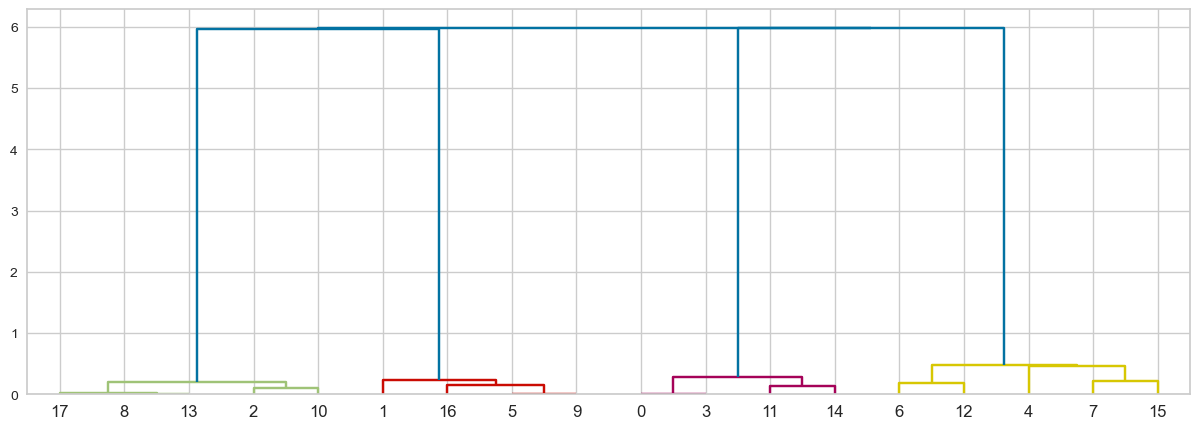

In [33]:
plt.figure(figsize=(15, 5))
dn = dendrogram(linkage(df2[['Component_1', 'Component_2', 'Component_3']], 'ward'))

По графику очевидно, что должно быть 4 кластера.

In [34]:
Z = linkage(df2[['Component_1', 'Component_2', 'Component_3']], method='ward') 
for k in range (2, 15):
    labels = fcluster(Z, t=k, criterion='maxclust')
    print('Число кластеров: {}, индекс {}'.format(k, calinski_harabasz_score(df2[['Component_1', 'Component_2', 'Component_3']], labels)))

Число кластеров: 2, индекс 7.956461050655492
Число кластеров: 3, индекс 14.737127450055631
Число кластеров: 4, индекс 671.661217508121
Число кластеров: 5, индекс 667.9450966781496
Число кластеров: 6, индекс 837.4622848735994
Число кластеров: 7, индекс 879.7356451506035
Число кластеров: 8, индекс 886.3188951151603
Число кластеров: 9, индекс 963.8009165692497
Число кластеров: 10, индекс 1123.875925095763
Число кластеров: 11, индекс 1482.6289751868537
Число кластеров: 12, индекс 2099.7817933589354
Число кластеров: 13, индекс 4141.62201949846
Число кластеров: 14, индекс 97347.3916239841


In [35]:
labels = fcluster(Z, t=4, criterion='maxclust')  # оставляем 4 кластера
df2['cluster_labels'] = labels
df2

,t1,t2,t3,t4,t5,t6,t7,t8,t9,t10,Component_1,Component_2,Component_3,cluster_labels
nr,,,,,,,,,,,,,,
1,10,10,9,10,10,10,9,10,10,9,0.952718,1.151277,1.138416,3
2,10,10,4,10,5,5,4,5,4,3,-1.189061,1.079824,-0.951928,2
3,5,4,10,5,10,4,10,5,3,10,0.969670,-0.788547,-0.966423,1
4,10,10,9,10,10,10,9,10,10,9,0.952718,1.151277,1.138416,3
5,4,3,5,4,3,10,4,10,10,5,-0.972416,-1.213946,0.929243,4
6,10,10,4,10,5,4,3,4,5,5,-1.093689,1.084139,-1.058630,2
7,4,4,5,5,4,10,5,10,10,6,-0.678341,-0.965220,0.963416,4
8,4,5,3,4,5,10,4,10,10,4,-1.056578,-0.930151,0.924343,4
9,4,5,10,4,10,5,10,4,3,10,0.970750,-0.904366,-0.964714,1


In [36]:
df2['cluster_labels'].value_counts()

1    5
4    5
3    4
2    4
Name: cluster_labels, dtype: int64

In [37]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 18 entries, 1 to 18
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   t1              18 non-null     int64  
 1   t2              18 non-null     int64  
 2   t3              18 non-null     int64  
 3   t4              18 non-null     int64  
 4   t5              18 non-null     int64  
 5   t6              18 non-null     int64  
 6   t7              18 non-null     int64  
 7   t8              18 non-null     int64  
 8   t9              18 non-null     int64  
 9   t10             18 non-null     int64  
 10  Component_1     18 non-null     float64
 11  Component_2     18 non-null     float64
 12  Component_3     18 non-null     float64
 13  cluster_labels  18 non-null     int32  
dtypes: float64(3), int32(1), int64(10)
memory usage: 2.0 KB


In [38]:
table = df2.groupby('cluster_labels')[['t1', 't2', 't3', 't4', 't5', 't6', 't7', 't8', 't9', 't10']].mean().T

table.index = ['Память на числа', 'Математические навыки', 'Готовность к прямому диалогу',
                        'Умение разрабатывать алгоритмы', 'Уверенность в речи', 'Командный дух',
                        'Находчивость', 'Навыки сотрудничества', 'Признание со стороны окружающих',
                        'Умение убеждать']

table

cluster_labels,1,2,3,4
Память на числа,4.2,10.00,10.00,4.8
Математические навыки,4.8,10.00,10.00,4.4
Готовность к прямому диалогу,10.0,4.25,9.00,4.0
Умение разрабатывать алгоритмы,4.4,10.00,10.00,4.0
Уверенность в речи,10.0,4.75,10.00,4.2
Командный дух,4.4,4.50,9.50,10.0
Находчивость,10.0,3.75,9.25,4.4
Навыки сотрудничества,4.0,4.25,9.75,10.0
Признание со стороны окружающих,3.8,4.25,10.00,10.0
Умение убеждать,10.0,4.25,9.50,5.0


In [39]:
# Добавить сюда описание кластеров

## 2. [Кластерный анализ методом k-means](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html) <a class="anchor" id="chapter2"></a>

### Пример 2.1. Синтетические данные<a id="section_2_1"></a>

In [40]:
np.random.seed(123)
X1 = np.random.randn(100,2)
X2 = np.random.randn(100,2) - np.array([10,1])
X3 = np.random.randn(100,2) - np.array([1,10])
X = np.vstack((X1,X2,X3))
y = np.array([1]*100 + [2]*100 + [3]*100)

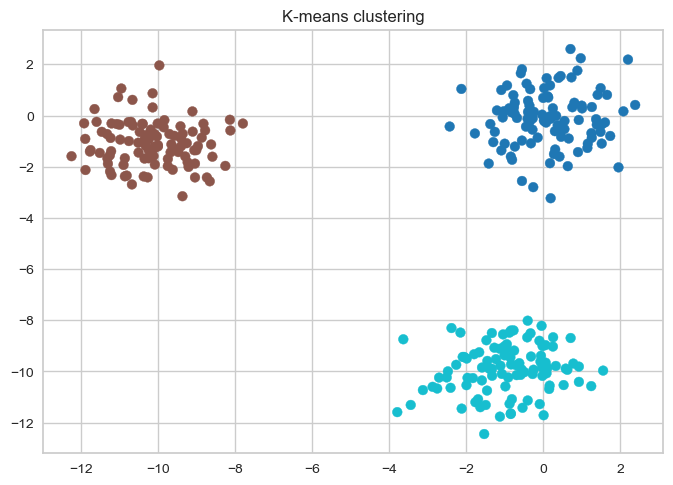

In [41]:
k_means = KMeans(n_clusters = 3)
k_means = k_means.fit(X)
clusters = k_means.predict(X)
plt.scatter(X[:,0], X[:,1], c = clusters, cmap='tab10')
plt.title('K-means clustering')
plt.show()

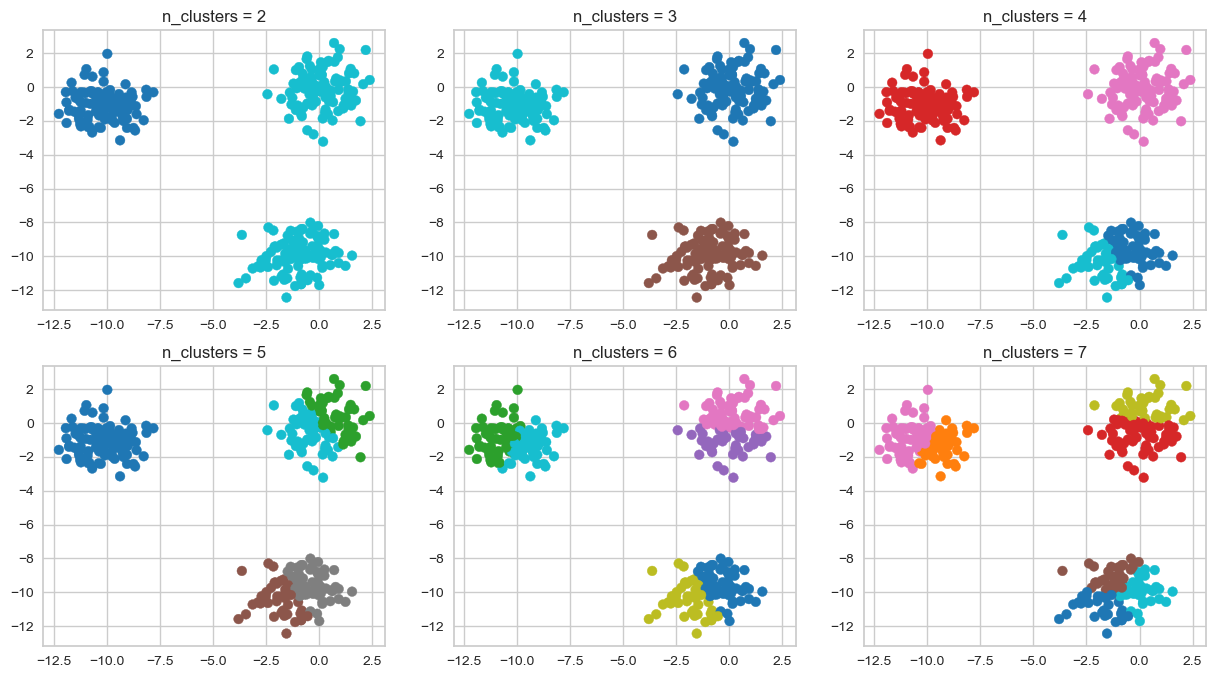

In [42]:
plt.figure(figsize= (15,8))
for n_c in range(2,8):
    k_means = KMeans(n_clusters = n_c)
    k_means = k_means.fit(X)
    clusters = k_means.predict(X)
    plt.subplot(2,3,n_c - 1)
    plt.scatter(X[:,0], X[:,1], c = clusters, cmap='tab10')
    plt.title('n_clusters = {}'.format(n_c))

plt.show()

Инерция вычисляется путем измерения расстояния между каждой точкой данных и ее центроидом, возведения этого расстояния в квадрат и суммирования этих квадратов по каждому кластеру. Мы стремимся к получению модели с низкой инерцией. 

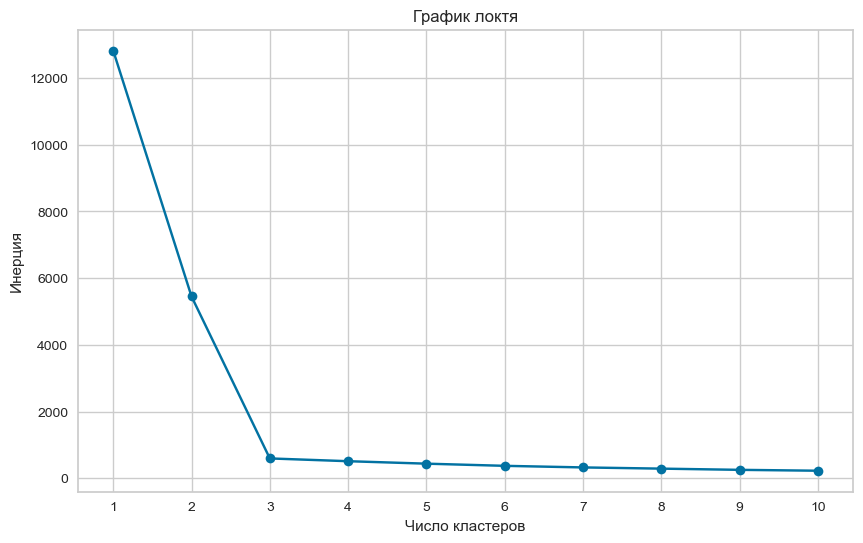

In [43]:
inertia = []
k_range = range(1, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=1)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, marker='o')
plt.title('График локтя')
plt.xlabel('Число кластеров')
plt.ylabel('Инерция')
plt.xticks(k_range)
plt.show()

На графике видно, что сначала инерция резко падает, в после 3-го кластера тоже снижается, но значительно медленней.

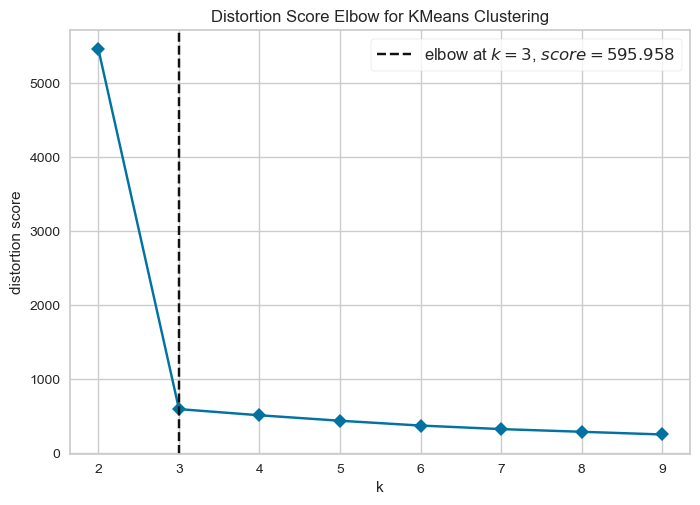

In [44]:
model = KMeans(random_state=1)
visualizer = KElbowVisualizer(model, k=(2,10), timings=False)

visualizer.fit(X)
visualizer.show()
plt.show()

Искажение (distortion score) — это среднее значение квадрата евклидового  расстояния от центроида до точек соответствующих кластеров. 

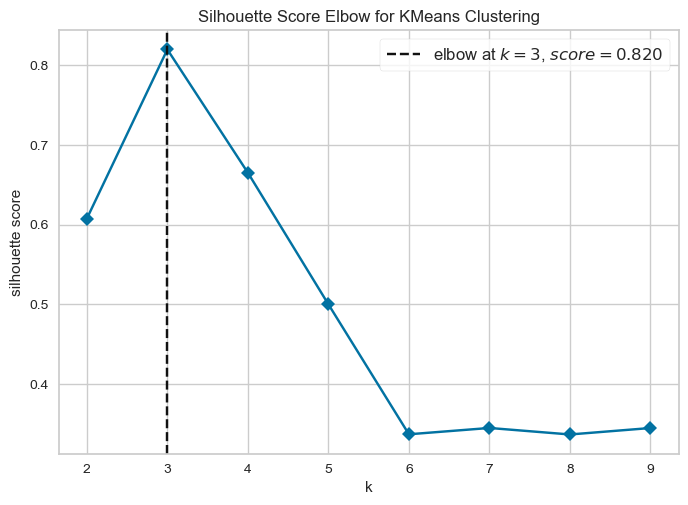

In [45]:
model = KMeans(random_state=1)
visualizer = KElbowVisualizer(model, k=(2,10), metric='silhouette', timings=False)

visualizer.fit(X)
visualizer.show()
plt.show()

Коэффициент силуэта (Silhouette Score) показывает, насколько каждый объект «похож» на другие объекты в том кластере, в который он был распределен в процессе кластеризации, и «не похож» на объекты из других кластеров.

В основе идеи метода лежит вычисление коэффициентов, которые присваиваются каждому объекту в кластере и образуют так называемый силуэт кластера. Коэффициенты изменяются от -1 до 1. Значения, близкие к 1, указывают на то, что объект является похожим на другие объекты в кластере и не похожим на объекты из других кластеров. Если большинство объектов имеют значения коэффициентов близкими к 1, можно утверждать, что кластерная структура хорошо выражена, и количество кластеров соответствует естественной группировке данных.

Можно вычислить среднее значение силуэта по всем наблюдениям и использовать его как метрику для оценки количества кластеров.

### Пример 2.2. [Текучесть кадров и производительность труда](https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset)<a id="section_2_2"></a>


In [46]:
df3 = pd.read_csv('Employee_Attrition.csv')
df3

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8


In [47]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

Для кластеризации отберем числовые признаки:
   - возраст в годах (Age),
   - расстояние от работы до дома в милях (DistanceFromHome)
   - ежемесячная зарплата (MonthlyIncome)
   - число компаний, в которых работал ранее (NumCompaniesWorked)
   - число лет работы в компании (YearsAtCompany)
   - число лет после последнего повышения (YearsSinceLastPromotion)

Проверим корреляцию между ними.

In [48]:
X = df3[['Age', 'DistanceFromHome', 'MonthlyIncome', 'NumCompaniesWorked', 
     'YearsAtCompany', 'YearsSinceLastPromotion' ]]

In [49]:
X.corr()

,Age,DistanceFromHome,MonthlyIncome,NumCompaniesWorked,YearsAtCompany,YearsSinceLastPromotion
Age,1.000000,-0.001686,0.497855,0.299635,0.311309,0.216513
DistanceFromHome,-0.001686,1.000000,-0.017014,-0.029251,0.009508,0.010029
MonthlyIncome,0.497855,-0.017014,1.000000,0.149515,0.514285,0.344978
NumCompaniesWorked,0.299635,-0.029251,0.149515,1.000000,-0.118421,-0.036814
YearsAtCompany,0.311309,0.009508,0.514285,-0.118421,1.000000,0.618409
YearsSinceLastPromotion,0.216513,0.010029,0.344978,-0.036814,0.618409,1.000000


Сильной мультиколлинеарности нет, можно приступать к кластеризации. Но перед этим стнадратизируем переменные, поскольку они измерены в разных шкалах.

In [50]:
X_zscore = zscore(X, axis=0)

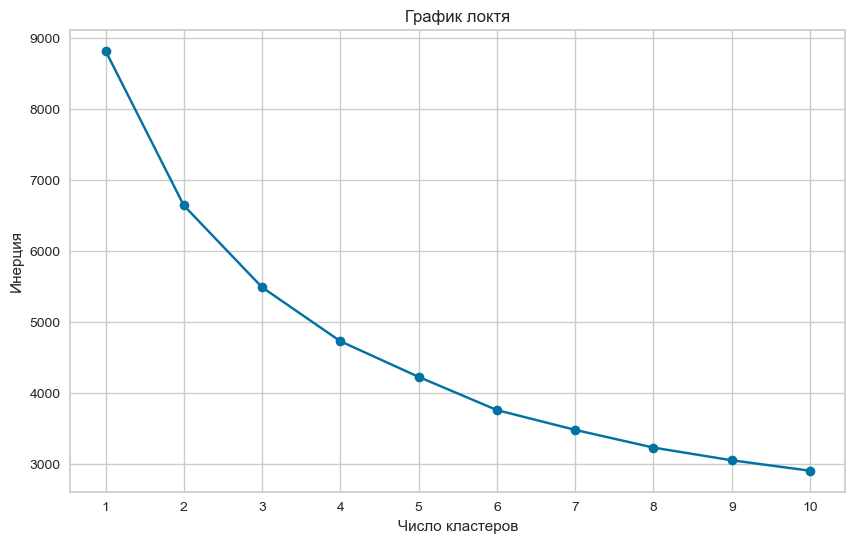

In [51]:
inertia = []
k_range = range(1, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=1)
    kmeans.fit(X_zscore)
    inertia.append(kmeans.inertia_)
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, marker='o')
plt.title('График локтя')
plt.xlabel('Число кластеров')
plt.ylabel('Инерция')
plt.xticks(k_range)
plt.show()

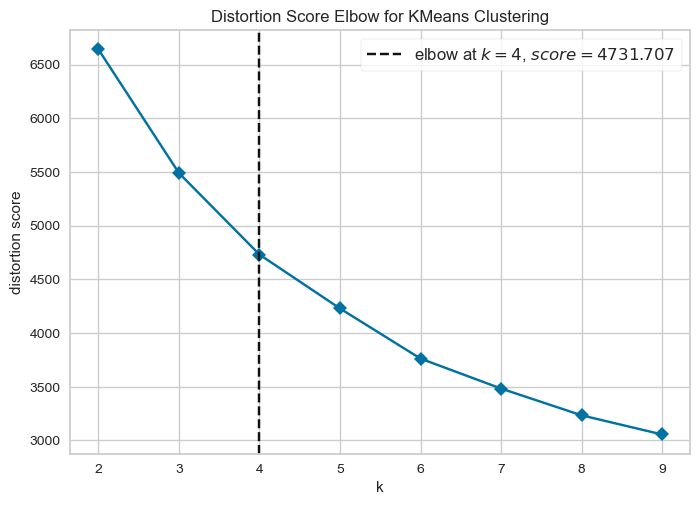

In [52]:
model = KMeans(random_state=1)
visualizer = KElbowVisualizer(model, k=(2,10), timings=False)

visualizer.fit(X_zscore)
visualizer.show()
plt.show()

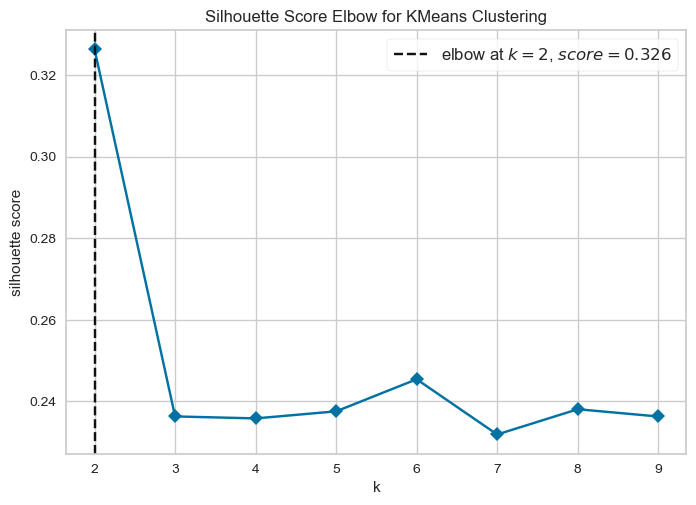

In [53]:
model = KMeans(random_state=1)
visualizer = KElbowVisualizer(model, k=(2,10), metric='silhouette', timings=False)

visualizer.fit(X_zscore)
visualizer.show()
plt.show()

Мы получили несколько противоречивые результаты. Однако лучше выбрать 4, а не 2 кластера, поскольку при 2 кластерах будет слишком общая картина. 

In [54]:
kmeans_model = KMeans(n_clusters=4).fit_predict(X_zscore)

In [55]:
df3['Clusters'] = kmeans_model
df3.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Clusters
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,80,0,8,0,1,6,4,0,5,1
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,80,1,10,3,3,10,7,1,7,0
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,80,0,7,3,3,0,0,0,0,1
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,80,0,8,3,3,8,7,3,0,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,80,1,6,3,3,2,2,2,2,1


In [56]:
df3['Clusters'].value_counts()

0    621
1    391
3    283
2    175
Name: Clusters, dtype: int64

In [57]:
df3.groupby('Clusters')[['Age', 'DistanceFromHome', 'MonthlyIncome', 'NumCompaniesWorked', 
     'YearsAtCompany', 'YearsSinceLastPromotion' ]].mean(numeric_only=True)

,Age,DistanceFromHome,MonthlyIncome,NumCompaniesWorked,YearsAtCompany,YearsSinceLastPromotion
Clusters,,,,,,
0,31.822866,5.301127,4313.560386,1.254428,5.677939,1.590982
1,42.680307,6.227621,7324.746803,5.516624,4.667519,1.138107
2,44.920000,8.600000,14170.885714,2.468571,18.662857,7.725714
3,35.219081,22.194346,5430.060071,2.088339,5.954064,1.522968


In [58]:
# Добавить сюда описание кластеров

## 3. DBSCAN <a class="anchor" id="chapter3"></a>

<p><a href="https://commons.wikimedia.org/wiki/File:DBSCAN-Illustration.svg#/media/Файл:DBSCAN-Illustration.svg"><img src="https://upload.wikimedia.org/wikipedia/commons/thumb/a/af/DBSCAN-Illustration.svg/1200px-DBSCAN-Illustration.svg.png" alt="DBSCAN-Illustration.svg" width="450" height="450"> </a><br>

### Пример 3.1. Синтетические данные<a id="section_3_1"></a>

In [59]:
np.random.seed(123)
X1 = np.random.randn(100,2)
X2 = np.random.randn(100,2) - np.array([10,1])
X3 = np.random.randn(100,2) - np.array([1,10])
X = np.vstack((X1,X2,X3))
y = np.array([1]*100 + [2]*100 + [3]*100)

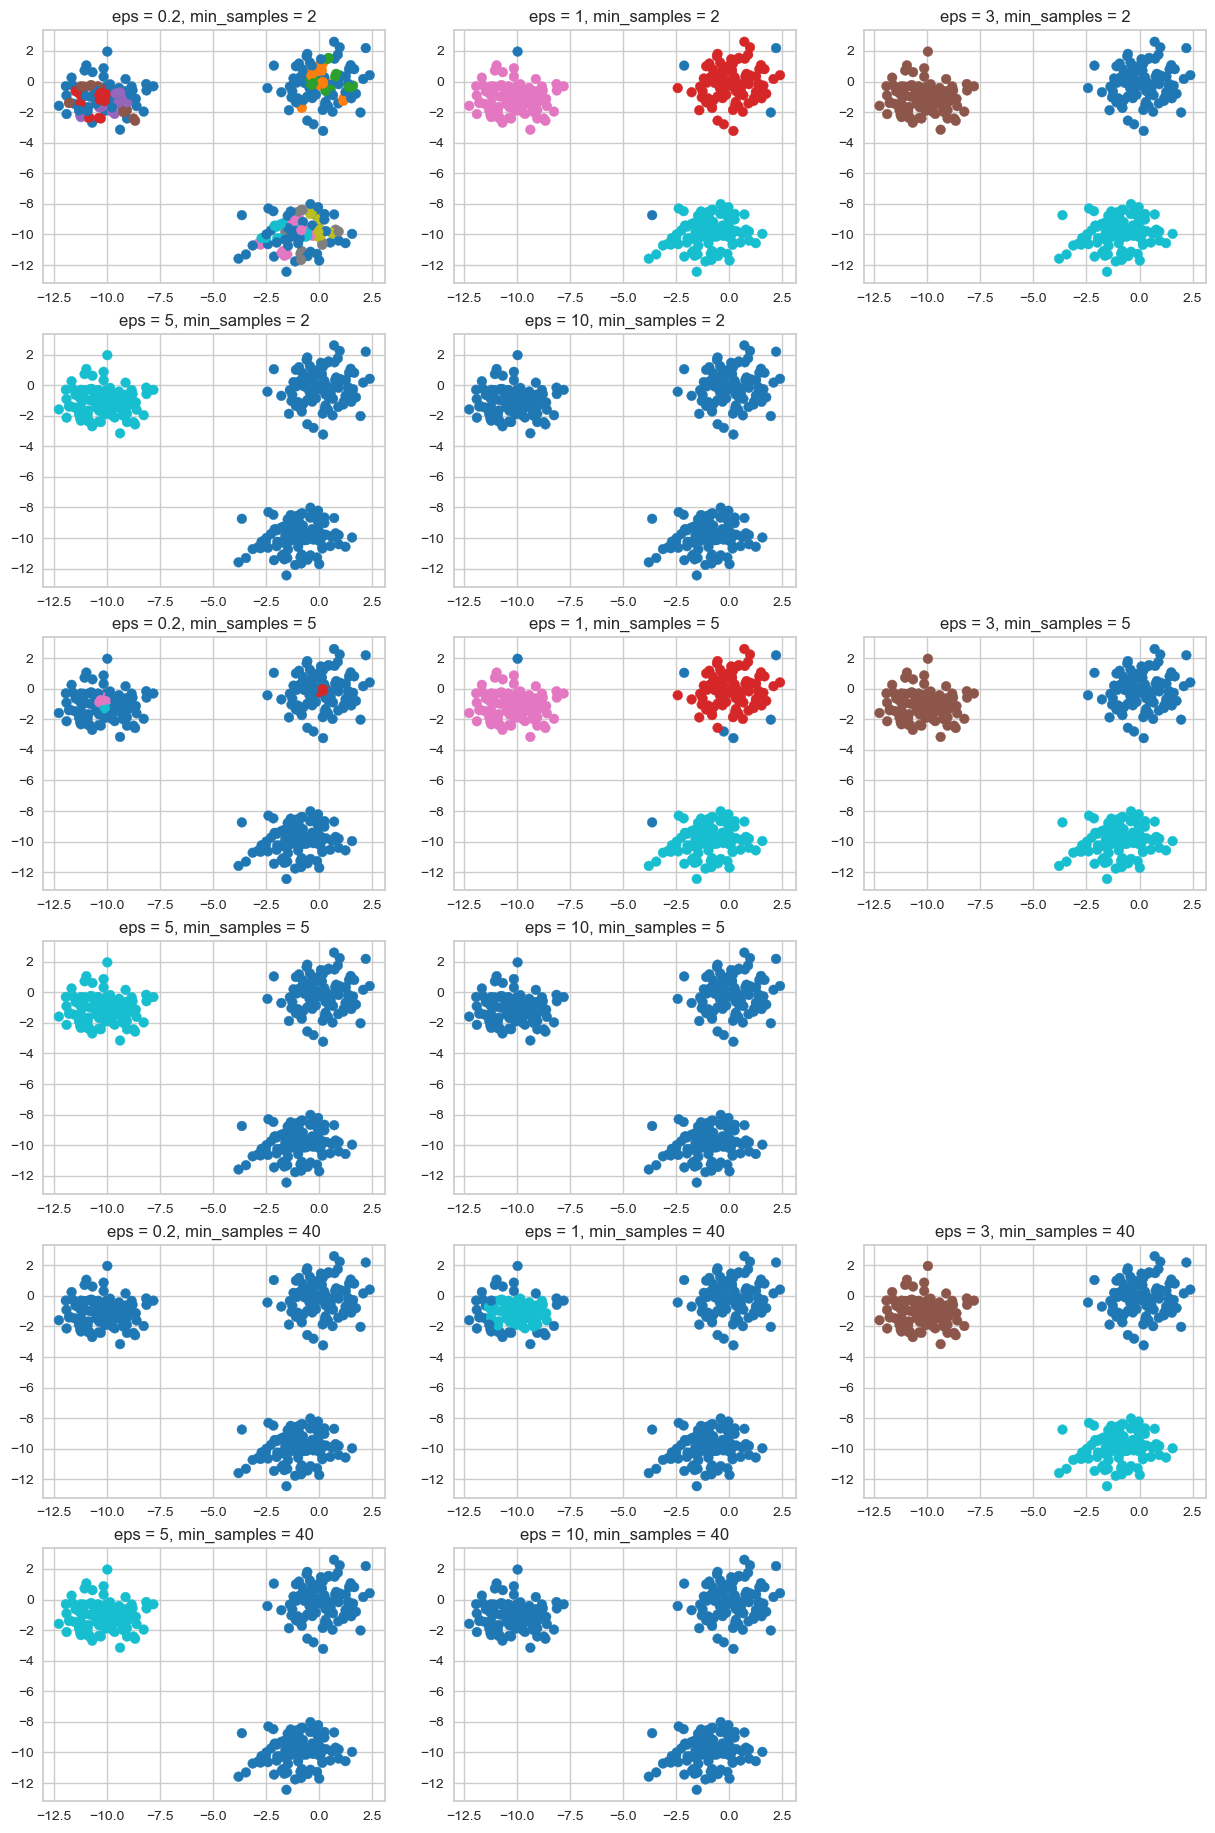

In [60]:
plt.figure(figsize= (15,23))
i = 1
for samples in [2, 5, 40]:
    for e in [0.2, 1, 3, 5, 10]:
        dbscan = DBSCAN(eps=e, min_samples=samples)
        clusters = dbscan.fit_predict(X)
        plt.subplot(6, 3, i)
        plt.scatter(X[:,0], X[:,1], c = clusters, cmap='tab10')
        plt.title('eps = {}, min_samples = {}'.format(e, samples))
        i += 1
    i+=1

plt.show()

### Пример 3.2. [Сегментация клиентов торгового центра](https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python)<a id="section_3_2"></a>

In [61]:
df4 = pd.read_csv('Mall_Customers.csv', index_col=0)
df4

,Gender,Age,Annual Income (k$),Spending Score (1-100)
CustomerID,,,,
1,Male,19,15,39
2,Male,21,15,81
3,Female,20,16,6
4,Female,23,16,77
5,Female,31,17,40
...,...,...,...,...
196,Female,35,120,79
197,Female,45,126,28
198,Male,32,126,74


In [62]:
df4.describe()

,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000
mean,38.850000,60.560000,50.200000
std,13.969007,26.264721,25.823522
min,18.000000,15.000000,1.000000
25%,28.750000,41.500000,34.750000
50%,36.000000,61.500000,50.000000
75%,49.000000,78.000000,73.000000
max,70.000000,137.000000,99.000000


In [63]:
df4.corr()

,Age,Annual Income (k$),Spending Score (1-100)
Age,1.000000,-0.012398,-0.327227
Annual Income (k$),-0.012398,1.000000,0.009903
Spending Score (1-100),-0.327227,0.009903,1.000000


In [64]:
X_numerics = df4[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

### Иерархический кластерный анализ

In [65]:
X_numerics_z = zscore(X_numerics, axis=0)

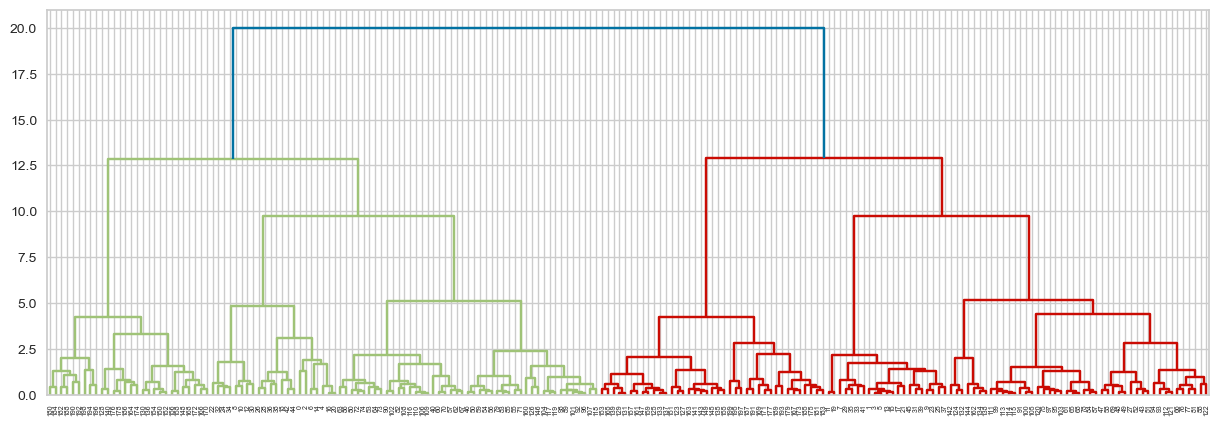

In [66]:
plt.figure(figsize=(15, 5))
dn = dendrogram(linkage(X_numerics_z, 'ward'))

In [67]:
Z = linkage(X_numerics_z, method='ward')

ks = range(2, 10)
scores = []

for k in ks:
    labels = fcluster(Z, t=k, criterion='maxclust')
    score = calinski_harabasz_score(X_numerics_z, labels)
    scores.append(score)
    print(f'Число кластеров: {k}, Индекс Калински-Харабаша: {score:.2f}')

Число кластеров: 2, Индекс Калински-Харабаша: 99.00
Число кластеров: 3, Индекс Калински-Харабаша: 88.10
Число кластеров: 4, Индекс Калински-Харабаша: 102.02
Число кластеров: 5, Индекс Калински-Харабаша: 107.83
Число кластеров: 6, Индекс Калински-Харабаша: 127.99
Число кластеров: 7, Индекс Калински-Харабаша: 120.69
Число кластеров: 8, Индекс Калински-Харабаша: 118.07
Число кластеров: 9, Индекс Калински-Харабаша: 117.48


In [68]:
labels = fcluster(Z, t=6, criterion='maxclust')
labels

array([2, 5, 2, 5, 2, 5, 2, 5, 2, 5, 2, 5, 2, 5, 2, 5, 2, 5, 2, 5, 2, 5,
       2, 5, 2, 5, 2, 6, 2, 5, 2, 5, 2, 5, 2, 5, 2, 5, 2, 5, 3, 5, 2, 6,
       2, 5, 3, 6, 6, 6, 3, 6, 6, 3, 3, 3, 3, 3, 6, 3, 3, 6, 3, 3, 3, 6,
       6, 3, 6, 6, 3, 3, 3, 3, 3, 6, 6, 6, 6, 3, 3, 6, 3, 3, 6, 3, 3, 6,
       6, 3, 3, 6, 3, 6, 6, 6, 3, 6, 3, 6, 6, 3, 3, 6, 3, 6, 3, 3, 3, 3,
       3, 6, 6, 6, 6, 6, 3, 3, 3, 3, 6, 6, 6, 4, 6, 4, 3, 4, 1, 4, 1, 4,
       6, 4, 6, 4, 1, 4, 6, 4, 1, 4, 6, 4, 6, 4, 3, 4, 1, 4, 1, 4, 1, 4,
       1, 4, 1, 4, 1, 4, 3, 4, 6, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4,
       1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4,
       1, 4], dtype=int32)

In [69]:
df4['Cluster_Hierarchical'] = labels  # добавление переменной с информацией о принадлежности к кластеру
df4

,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster_Hierarchical
CustomerID,,,,,
1,Male,19,15,39,2
2,Male,21,15,81,5
3,Female,20,16,6,2
4,Female,23,16,77,5
5,Female,31,17,40,2
...,...,...,...,...,...
196,Female,35,120,79,4
197,Female,45,126,28,1
198,Male,32,126,74,4


### Описательная статистика по кластерам

In [70]:
df4.groupby('Cluster_Hierarchical')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean()

,Age,Annual Income (k$),Spending Score (1-100)
Cluster_Hierarchical,,,
1,43.892857,91.285714,16.678571
2,44.318182,25.772727,20.272727
3,56.400000,55.288889,48.355556
4,32.692308,86.538462,82.128205
5,24.809524,25.619048,80.238095
6,27.377778,57.511111,45.844444


In [71]:
df4['Cluster_Hierarchical'].value_counts()

6    45
3    45
4    39
1    28
2    22
5    21
Name: Cluster_Hierarchical, dtype: int64

## Алгоритм k-means

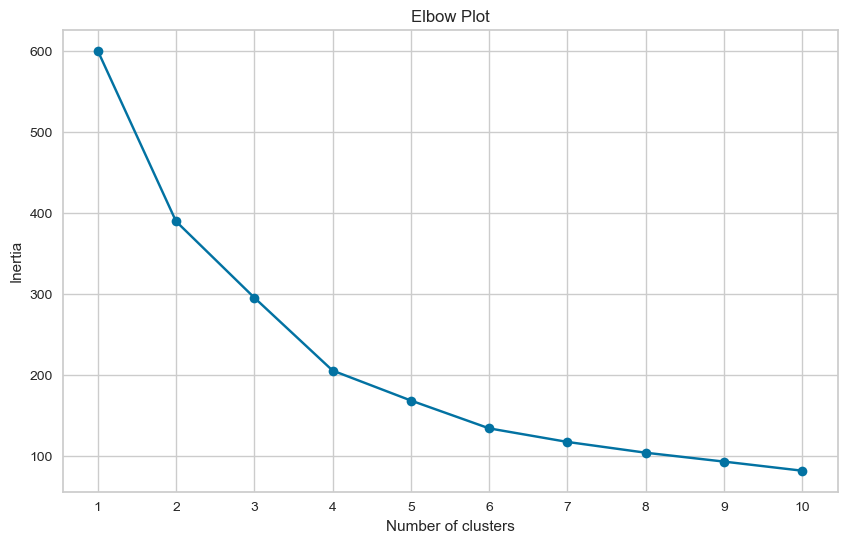

In [72]:
inertia = []
k_range = range(1, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=1)
    kmeans.fit(X_numerics_z)
    inertia.append(kmeans.inertia_)
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, marker='o')
plt.title('Elbow Plot')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.xticks(k_range)
plt.show()

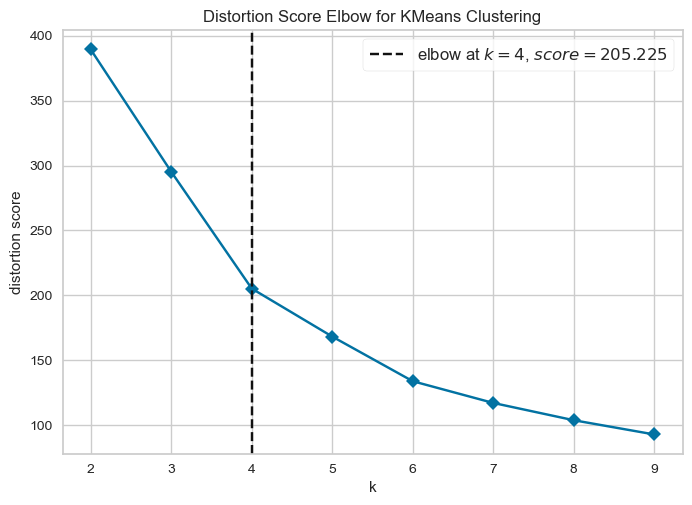

In [73]:
model = KMeans(random_state=1)
visualizer = KElbowVisualizer(model, k=(2,10), timings=False)

visualizer.fit(X_numerics_z)
visualizer.show()
plt.show()

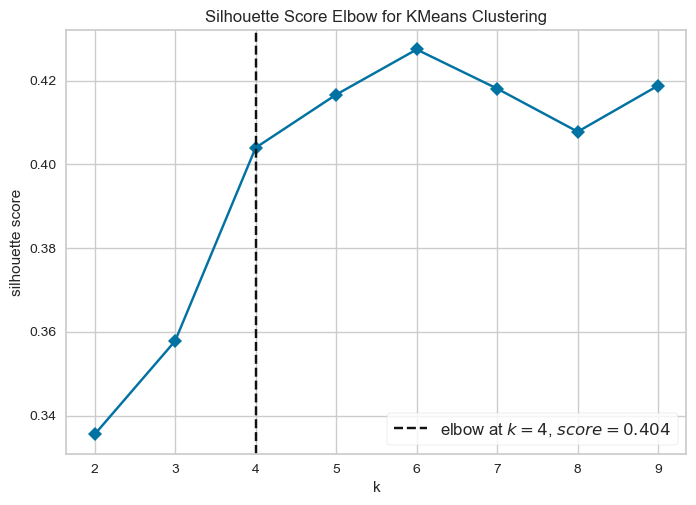

In [74]:
model = KMeans(random_state=1)
visualizer = KElbowVisualizer(model, k=(2,10), metric='silhouette', timings=False)

visualizer.fit(X_numerics_z)
visualizer.show()
plt.show()

In [75]:
kmeans_model = KMeans(n_clusters=4).fit_predict(X_numerics_z)

In [76]:
df4['Clusters_k-means'] = kmeans_model
df4.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster_Hierarchical,Clusters_k-means
CustomerID,,,,,,
1,Male,19,15,39,2,3
2,Male,21,15,81,5,3
3,Female,20,16,6,2,3
4,Female,23,16,77,5,3
5,Female,31,17,40,2,3


In [77]:
df4['Clusters_k-means'].value_counts()

0    65
3    57
1    40
2    38
Name: Clusters_k-means, dtype: int64

In [78]:
df4.groupby('Clusters_k-means')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean(numeric_only=True)

,Age,Annual Income (k$),Spending Score (1-100)
Clusters_k-means,,,
0,53.984615,47.707692,39.969231
1,32.875000,86.100000,81.525000
2,39.368421,86.500000,19.578947
3,25.438596,40.000000,60.298246


## DBSCAN

Мы не знаем какими должны быть значения радиуса окрестности и минимального числа соседей. Будем подбирать на основе коэффициента силуэта.

In [79]:
eps_values = np.arange(8,12.75,0.25)  # рассматриваемые значения радиуса окрестности
min_samples = np.arange(3,10)  # рассматриваемые значение минимального числа соседей

DBSCAN_params = list(product(eps_values, min_samples))

In [80]:
no_of_clusters = []
sil_score = []

for p in DBSCAN_params:
    DBS_clustering = DBSCAN(eps=p[0], min_samples=p[1]).fit(X_numerics)
    no_of_clusters.append(len(np.unique(DBS_clustering.labels_)))
    sil_score.append(silhouette_score(X_numerics, DBS_clustering.labels_))

Тепловая карта ниже показывает, сколько кластеров было создано алгоритмом DBSCAN для соответствующих комбинаций параметров.

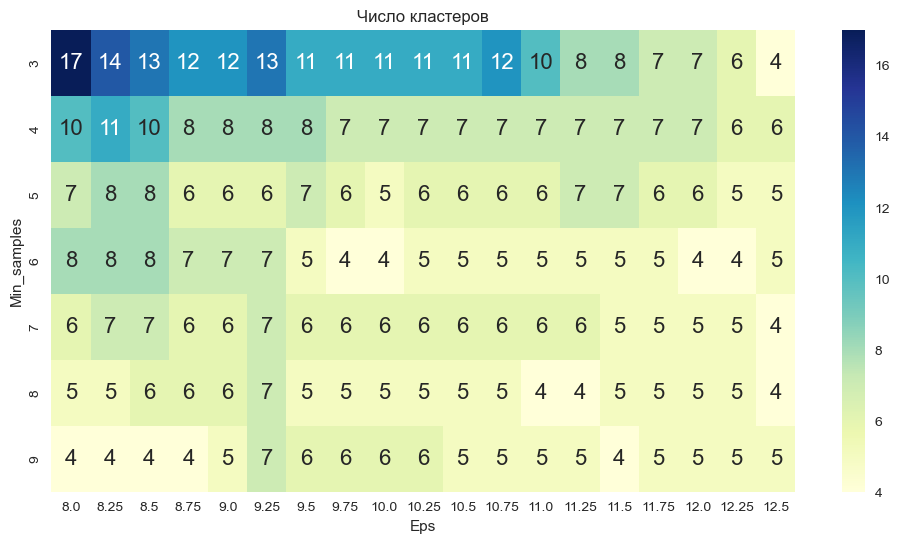

In [81]:
tmp = pd.DataFrame.from_records(DBSCAN_params, columns =['Eps', 'Min_samples'])   
tmp['No_of_clusters'] = no_of_clusters

pivot_1 = pd.pivot_table(tmp, values='No_of_clusters', index='Min_samples', columns='Eps')

fig, ax = plt.subplots(figsize=(12,6))
sns.heatmap(pivot_1, annot=True, annot_kws={"size": 16}, cmap="YlGnBu", ax=ax)
ax.set_title('Число кластеров')
plt.show()

Количество кластеров варьируется от 4 до 17. Однако большинство комбинаций дает 4-7 кластеров. Чтобы решить, какую комбинацию выбрать, мы будем использовать коэффициент силуэта и снова изобразим его значения на тепловой карте.

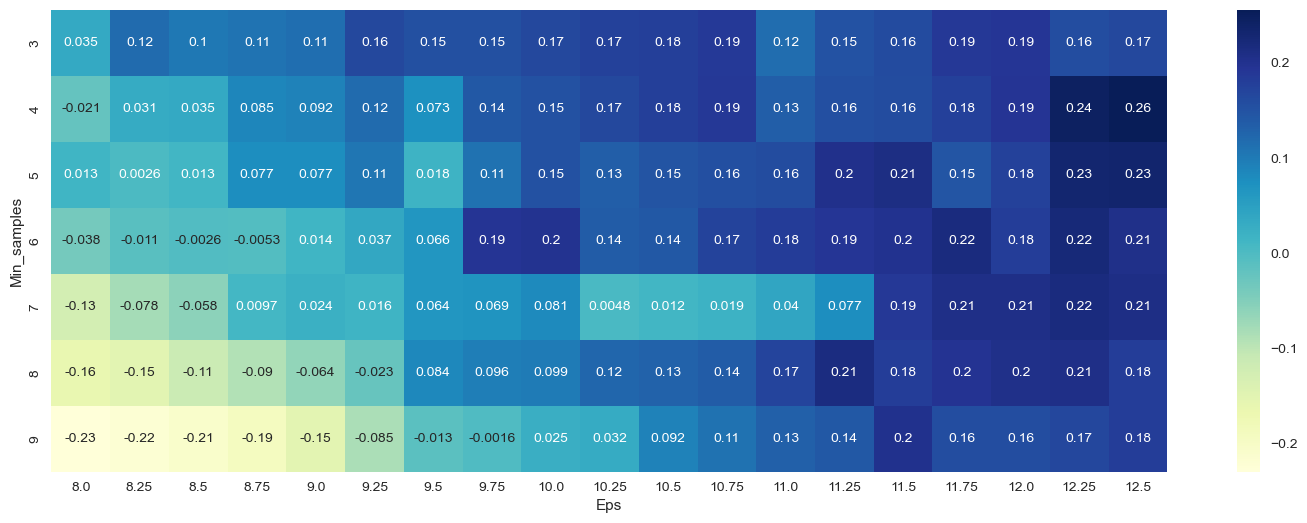

In [82]:
tmp = pd.DataFrame.from_records(DBSCAN_params, columns =['Eps', 'Min_samples'])   
tmp['Sil_score'] = sil_score

pivot_1 = pd.pivot_table(tmp, values='Sil_score', index='Min_samples', columns='Eps')

fig, ax = plt.subplots(figsize=(18,6))
sns.heatmap(pivot_1, annot=True, annot_kws={"size": 10}, cmap="YlGnBu", ax=ax)
plt.show()

Максимальное значение коэффициента силуэта равно 0,26 для eps=12,5 и min_samples=4.

In [83]:
DBS_clustering = DBSCAN(eps=12.5, min_samples=4).fit(X_numerics)

DBSCAN_clustered = X_numerics.copy()
DBSCAN_clustered.loc[:,'Cluster'] = DBS_clustering.labels_

In [84]:
DBSCAN_clust_sizes = DBSCAN_clustered.groupby('Cluster').size().to_frame()
DBSCAN_clust_sizes.columns = ["DBSCAN_size"]
DBSCAN_clust_sizes

,DBSCAN_size
Cluster,
-1,18
0,112
1,8
2,34
3,24
4,4


DBSCAN создал 5 кластеров плюс кластер выбросов (-1). Размеры кластеров 0-4 значительно различаются - некоторые имеют только 4 или 8 наблюдений. Всего 18 выбросов.

In [85]:
df4['Cluster_DBSCAN'] = DBS_clustering.labels_
df4

,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster_Hierarchical,Clusters_k-means,Cluster_DBSCAN
CustomerID,,,,,,,
1,Male,19,15,39,2,3,0
2,Male,21,15,81,5,3,0
3,Female,20,16,6,2,3,-1
4,Female,23,16,77,5,3,0
5,Female,31,17,40,2,3,0
...,...,...,...,...,...,...,...
196,Female,35,120,79,4,1,-1
197,Female,45,126,28,1,2,-1
198,Male,32,126,74,4,1,-1


In [86]:
df4['Cluster_DBSCAN'].value_counts()

 0    112
 2     34
 3     24
-1     18
 1      8
 4      4
Name: Cluster_DBSCAN, dtype: int64

In [87]:
df4.groupby('Cluster_DBSCAN')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean(numeric_only=True)

,Age,Annual Income (k$),Spending Score (1-100)
Cluster_DBSCAN,,,
-1,36.944444,74.000,44.944444
0,39.142857,48.250,52.339286
1,53.250000,27.750,9.500000
2,32.882353,82.000,83.235294
3,45.583333,85.875,17.958333
4,20.750000,76.250,8.000000


In [ ]:
# Добавить сюда описание кластеров